https://archive.ics.uci.edu/ml/datasets/Wholesale+customers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import DBSCAN

%config InlineBackend.figure_format = 'retina'

In [2]:
data = pd.read_csv('../DATA/wholesome_customers_data.csv')

In [3]:
data

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
data['Channel'].value_counts()

Channel
1    298
2    142
Name: count, dtype: int64

In [6]:
data['Region'].value_counts()

Region
3    316
1     77
2     47
Name: count, dtype: int64

<Axes: xlabel='Milk', ylabel='Grocery'>

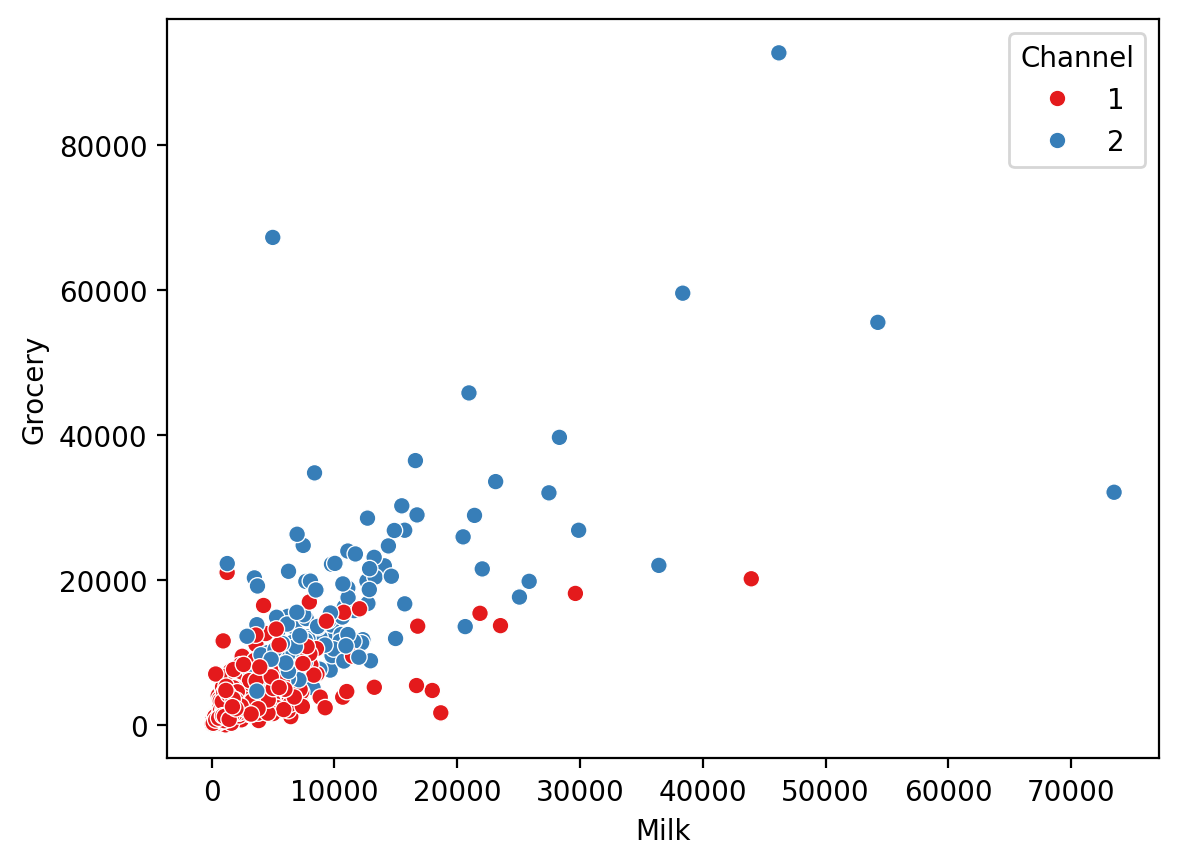

In [7]:
sns.scatterplot(x = 'Milk', y = 'Grocery', hue = 'Channel', data = data, palette = 'Set1')

<Axes: xlabel='Milk', ylabel='Count'>

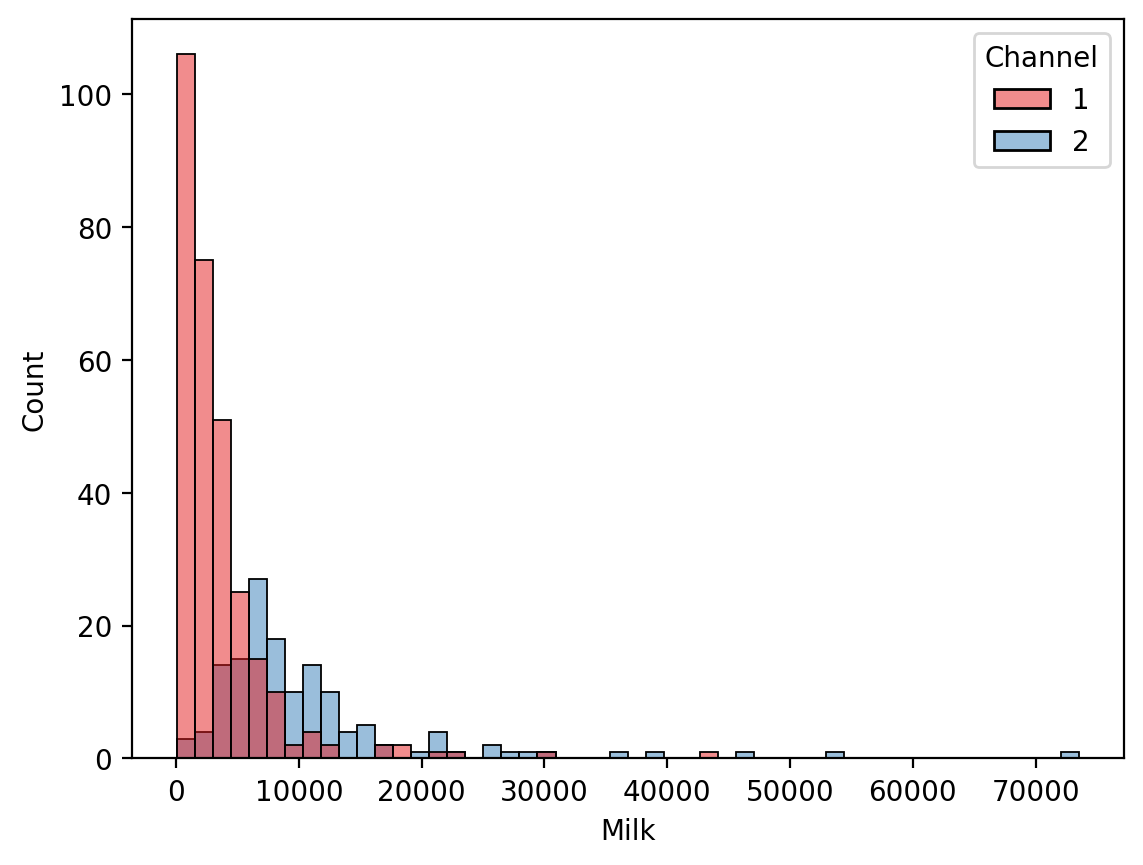

In [8]:
sns.histplot(x = 'Milk', hue = 'Channel', data = data, palette = 'Set1')

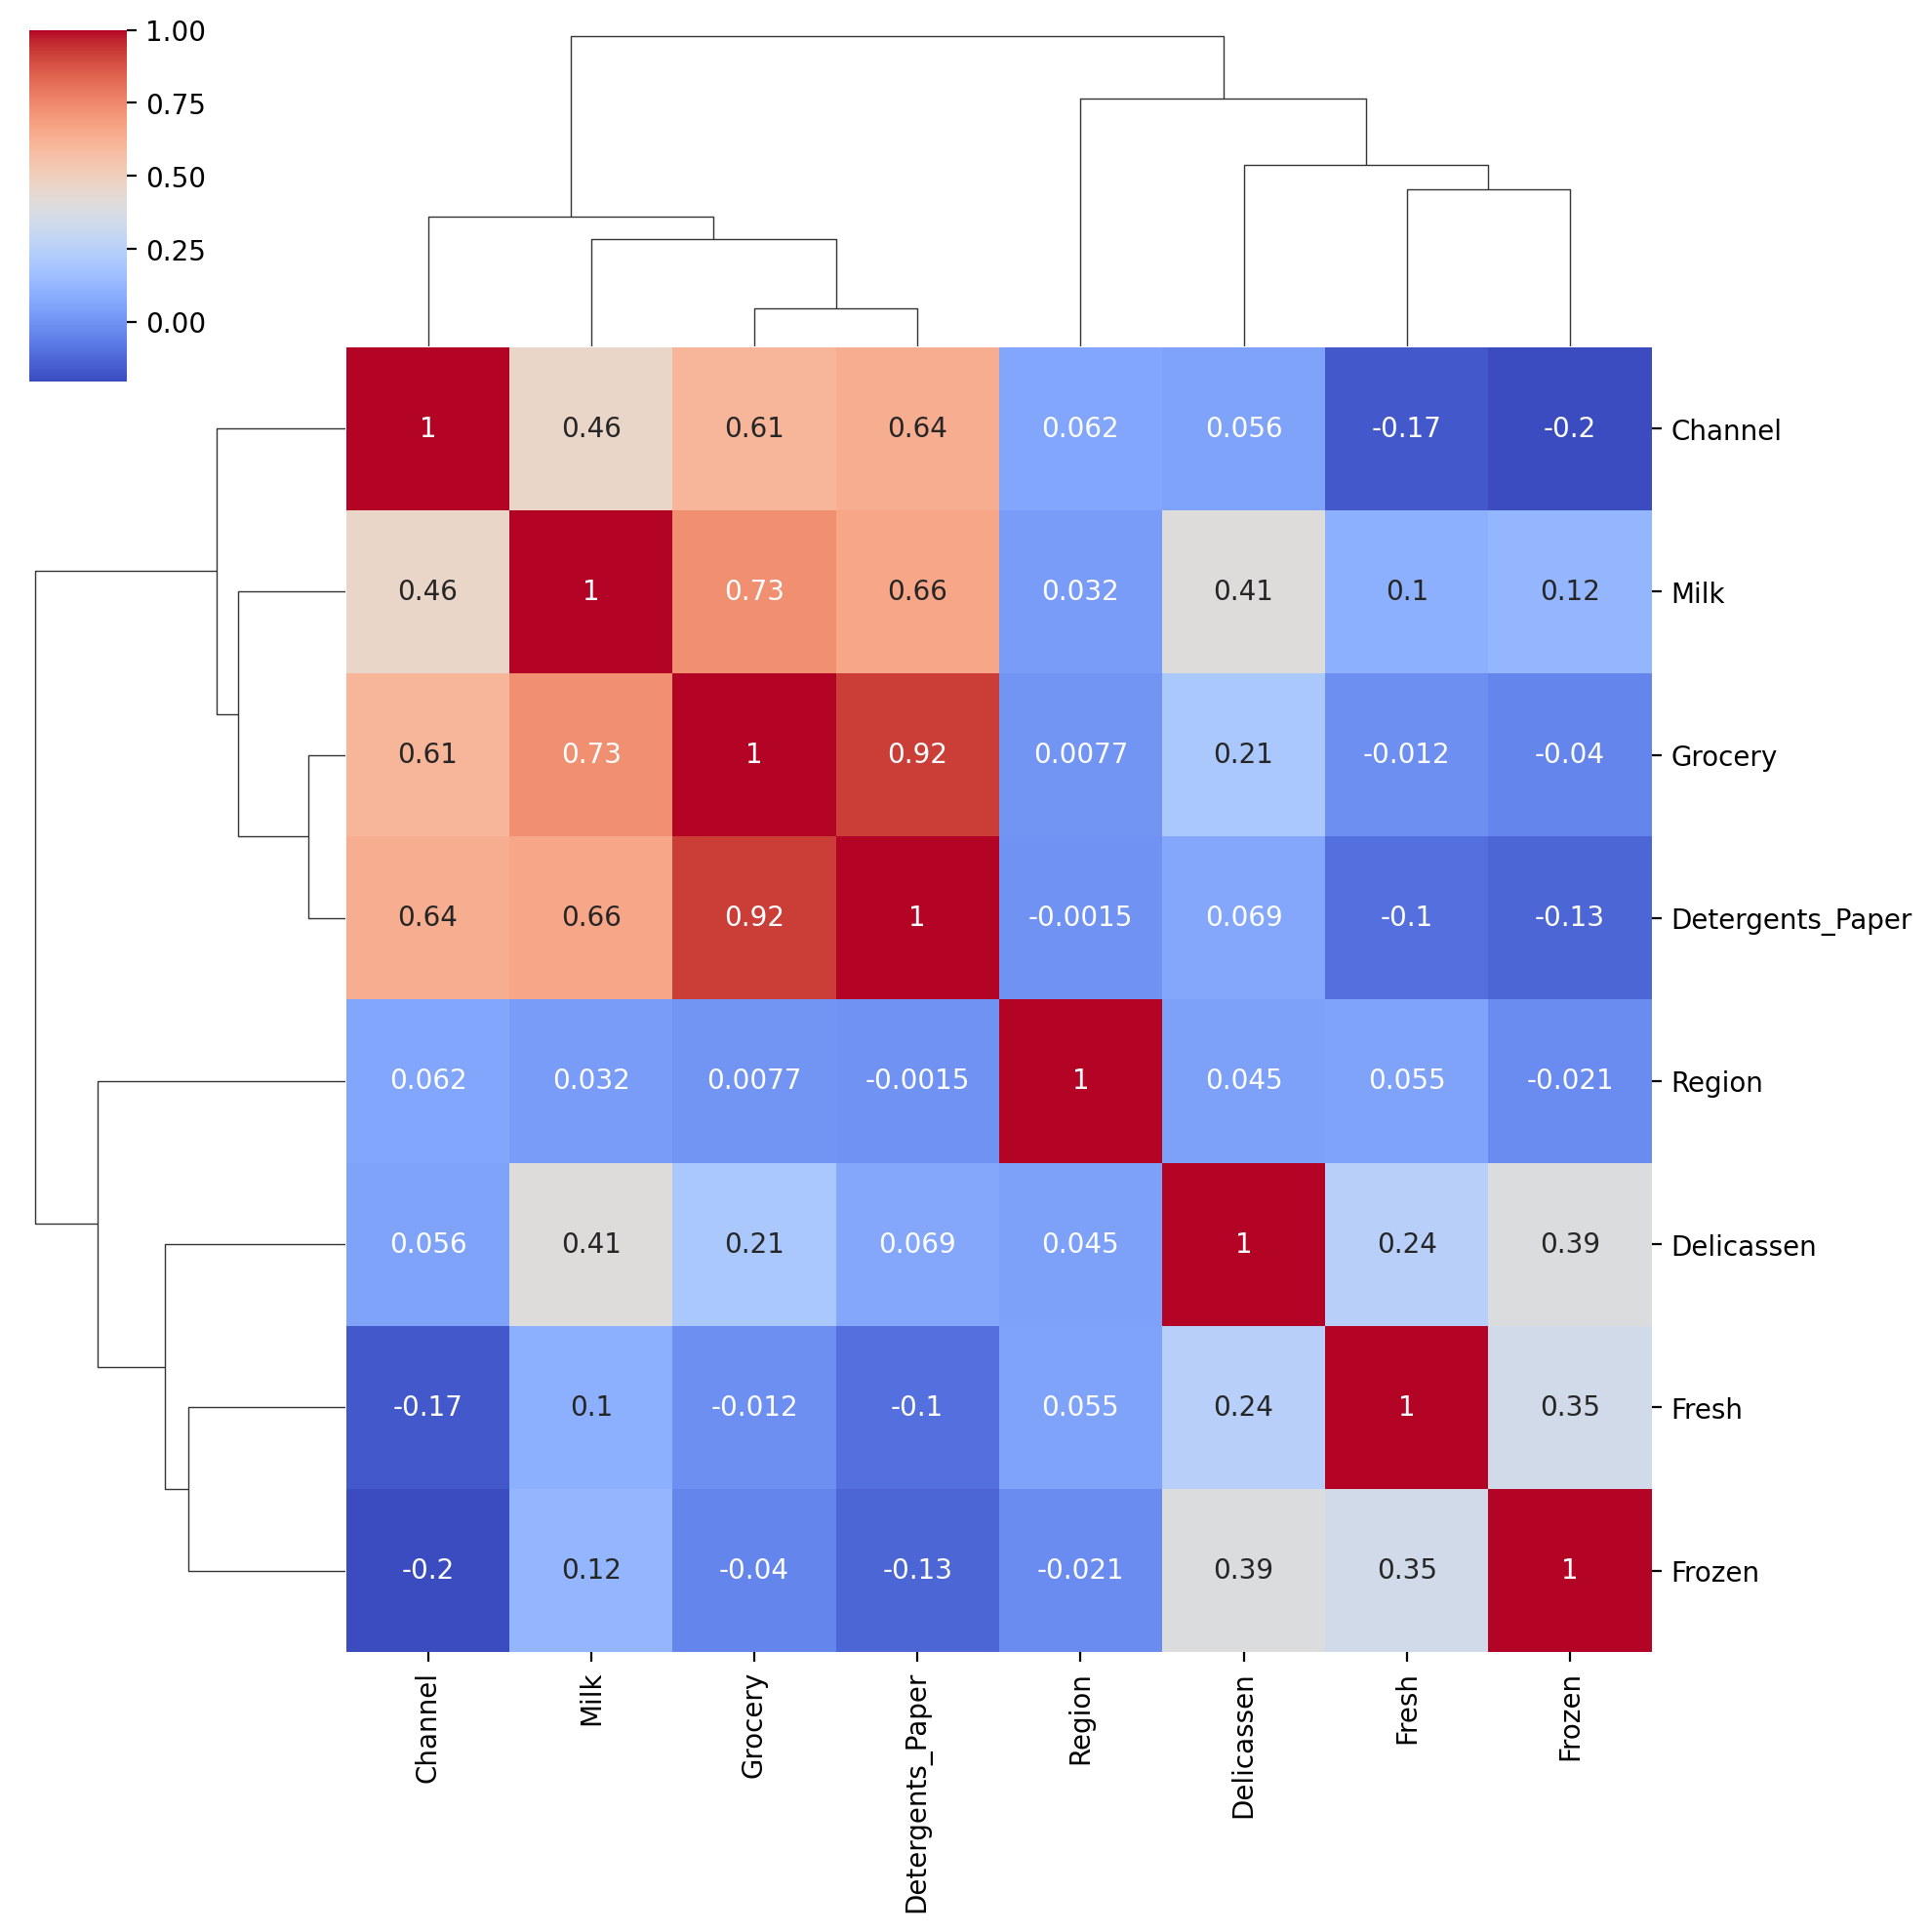

In [9]:
sns.clustermap(data.corr(), annot = True, cmap = 'coolwarm')

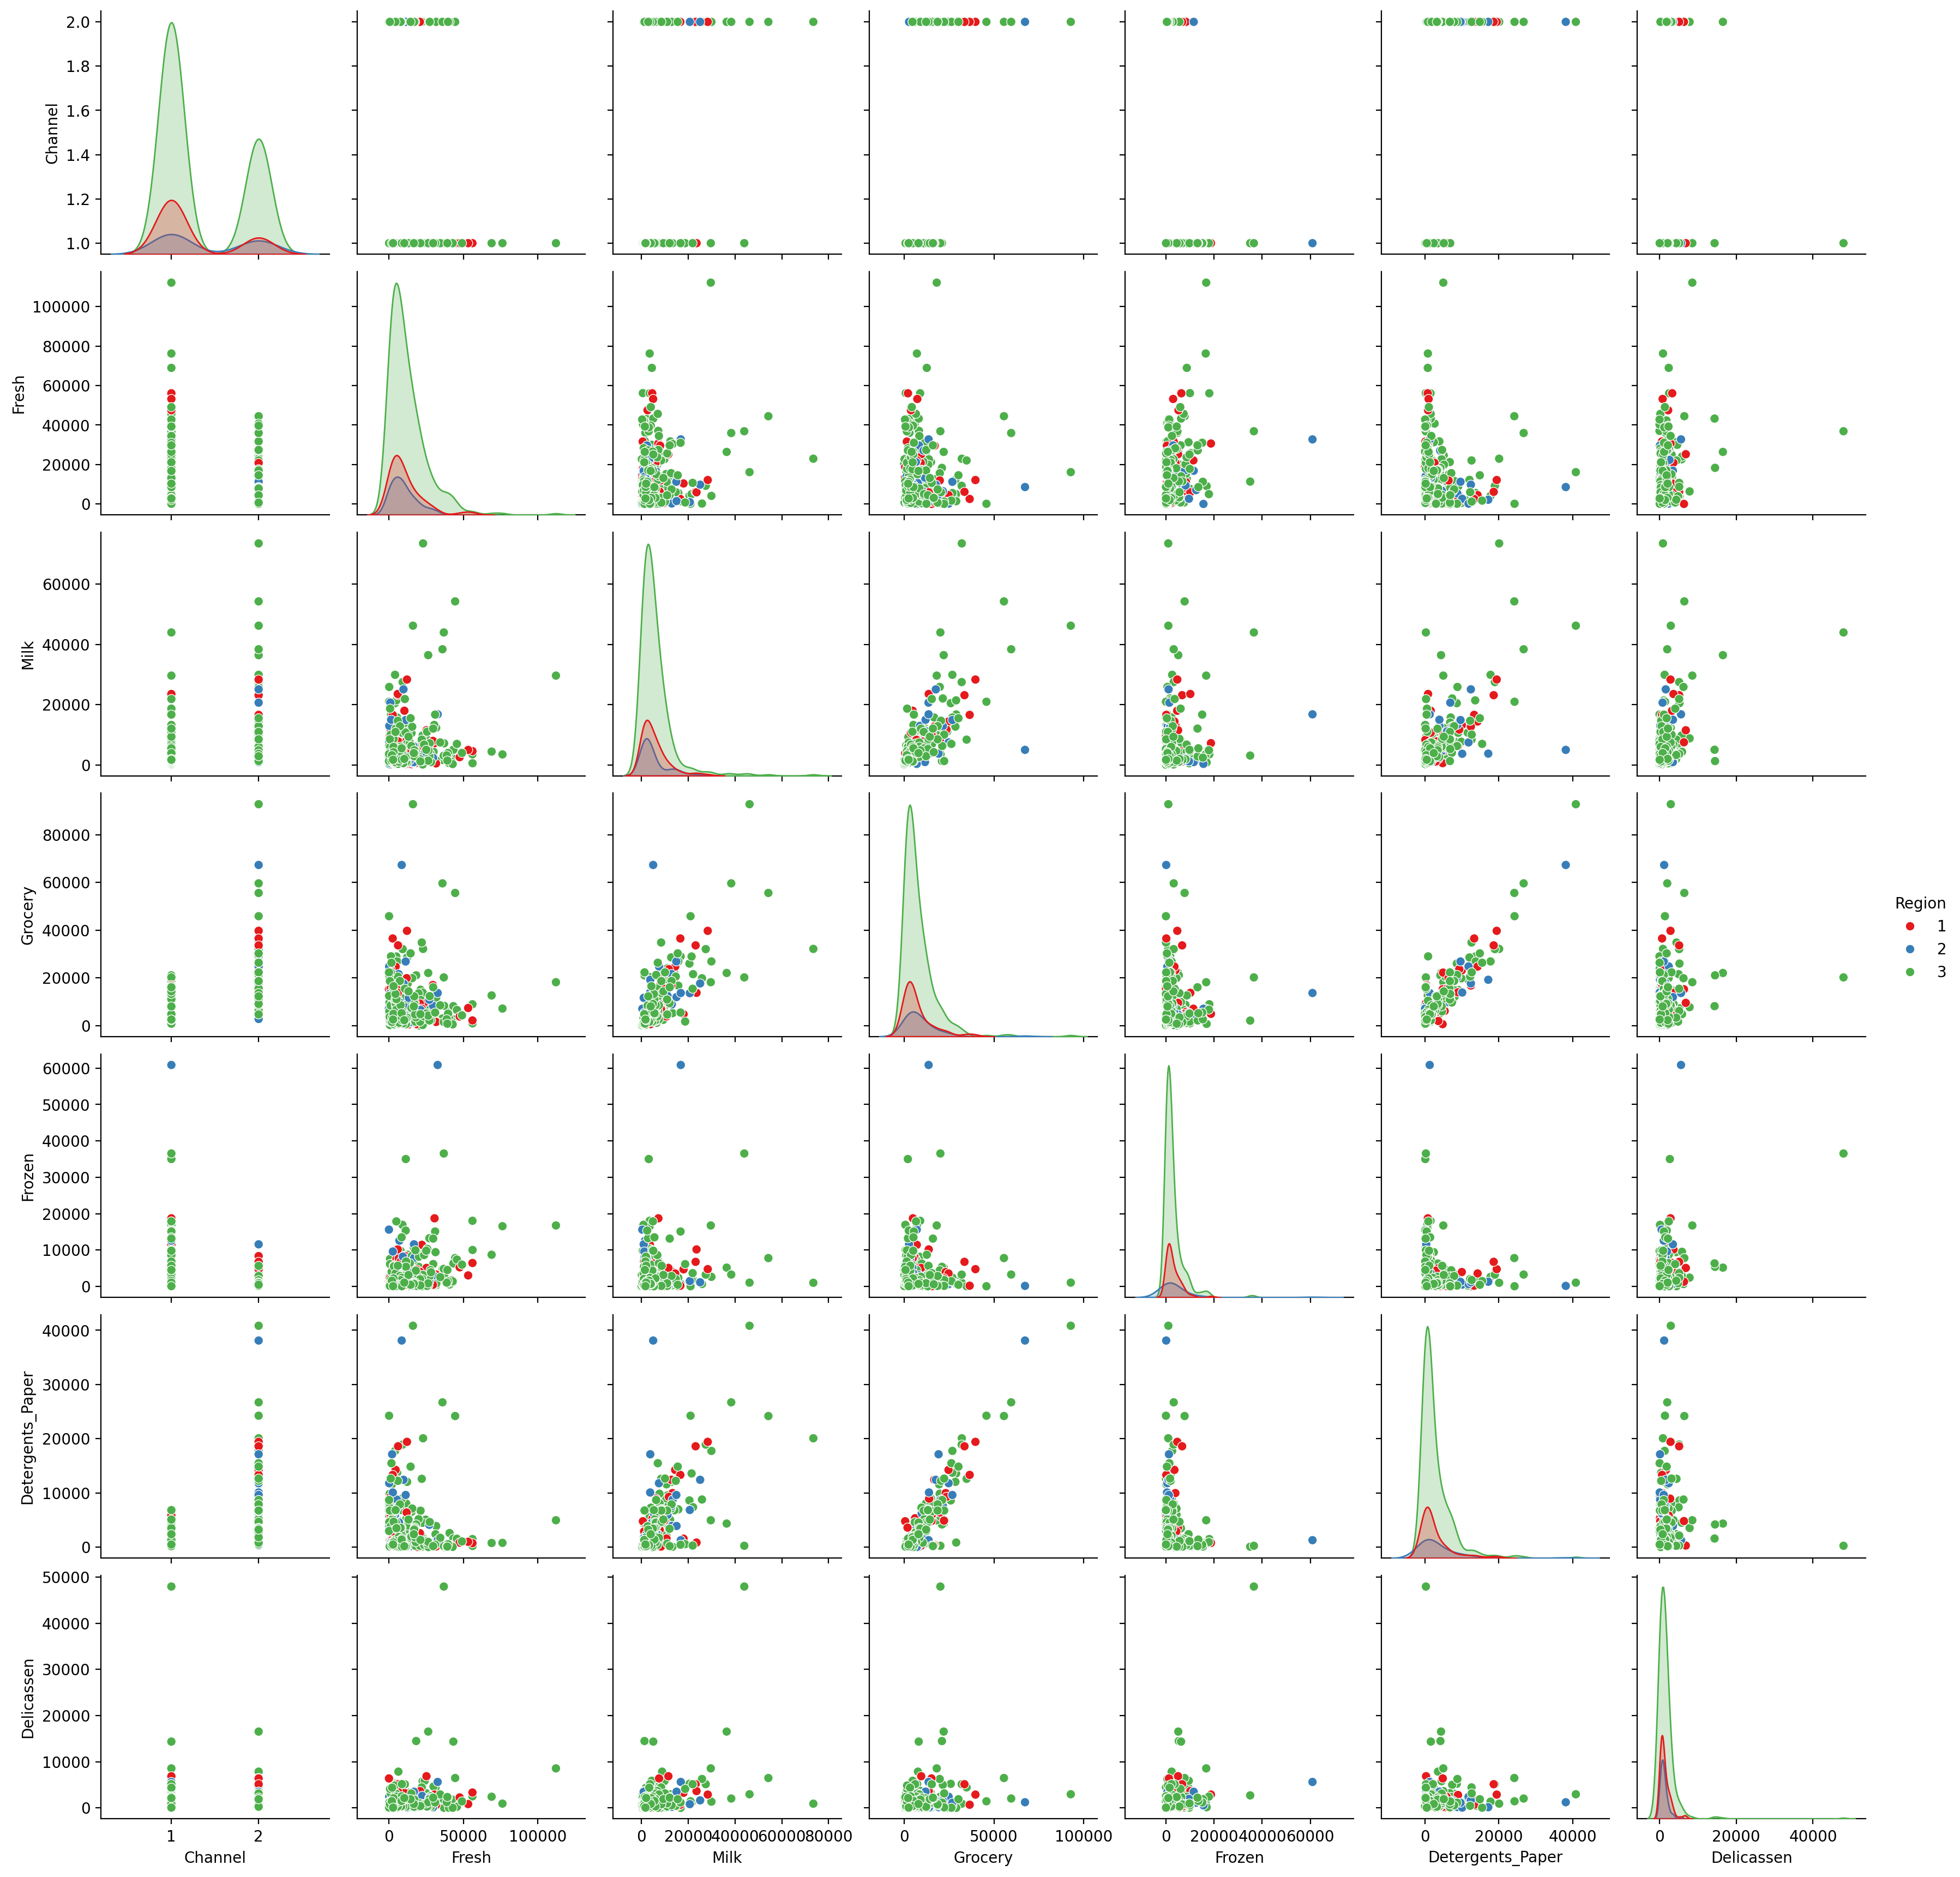

In [10]:
sns.pairplot(data, hue = 'Region', palette = 'Set1')

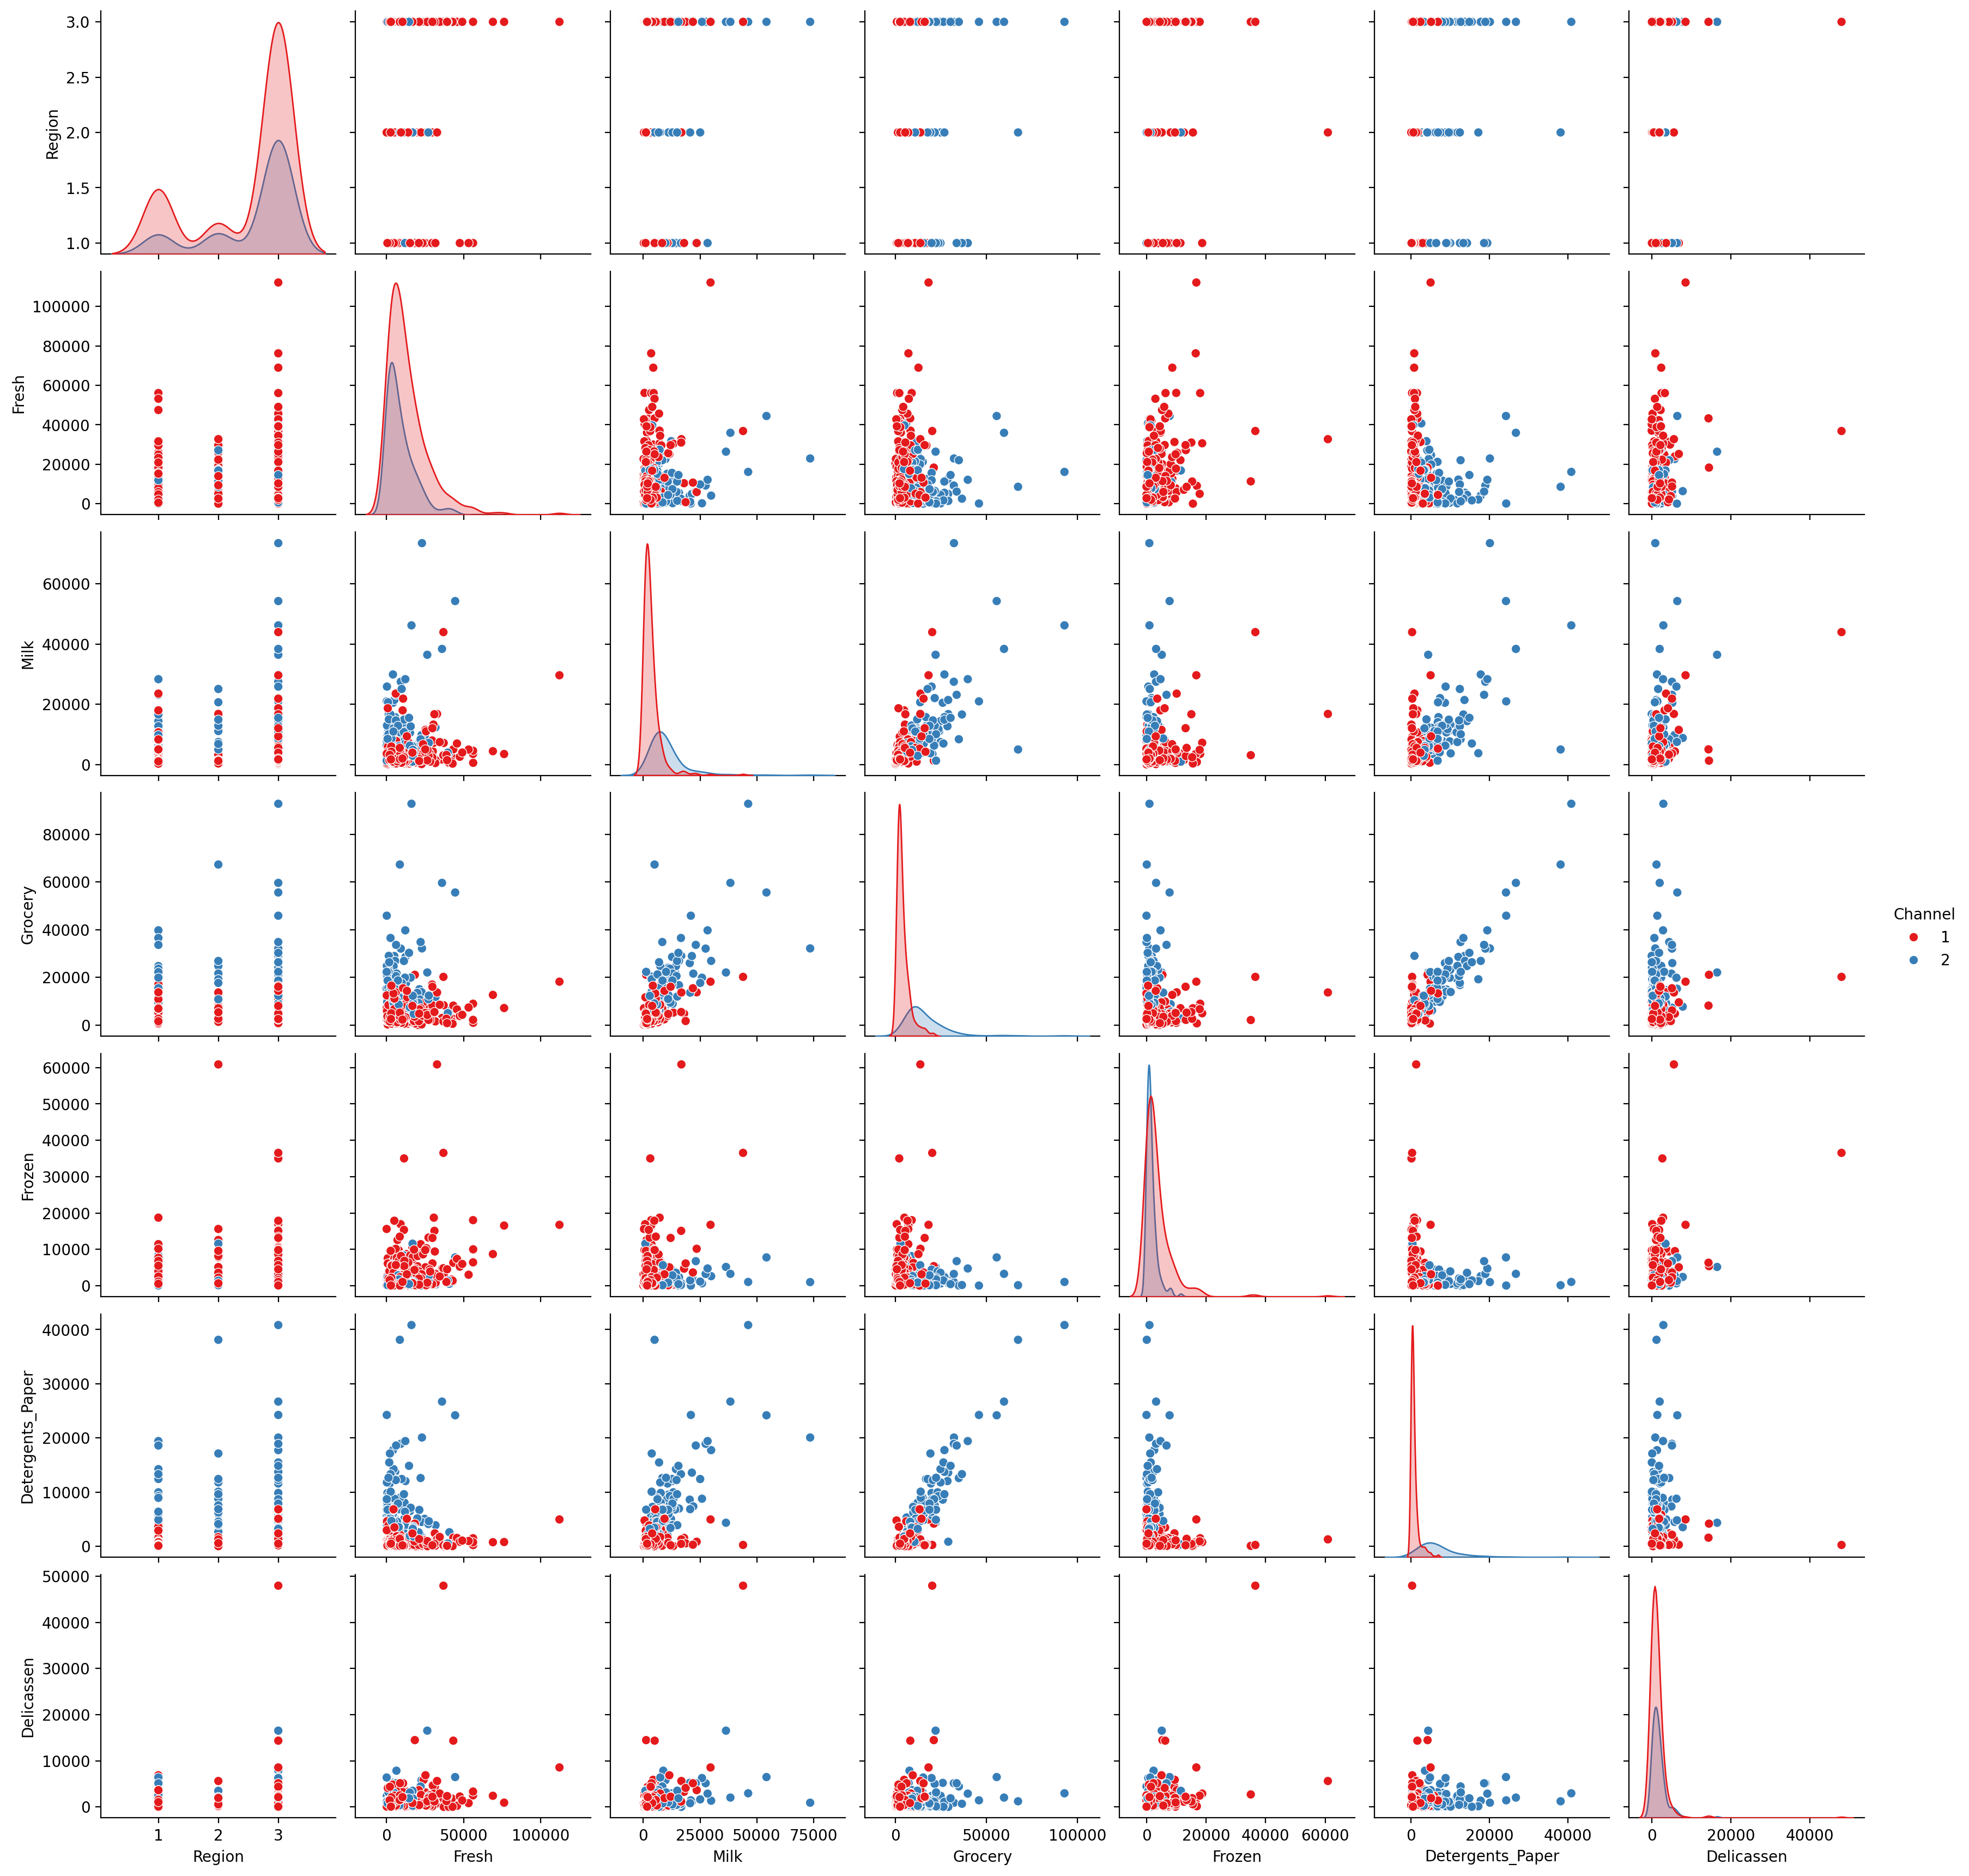

In [11]:
sns.pairplot(data, hue = 'Channel', palette = 'Set1')

In [12]:
scaler = StandardScaler()

In [13]:
scaled_data = scaler.fit_transform(data)

In [14]:
scaled_data

array([[ 1.44865163,  0.59066829,  0.05293319, ..., -0.58936716,
        -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197, ..., -0.27013618,
         0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926, ..., -0.13753572,
         0.13323164,  2.24329255],
       ...,
       [ 1.44865163,  0.59066829,  0.20032554, ..., -0.54337975,
         2.51121768,  0.12145607],
       [-0.69029709,  0.59066829, -0.13538389, ..., -0.41944059,
        -0.56977032,  0.21304614],
       [-0.69029709,  0.59066829, -0.72930698, ..., -0.62009417,
        -0.50488752, -0.52286938]])

In [15]:
outliers = [ ]
outlier_percent = [ ]

for i in np.linspace(0.001, 10, 100):
    model = DBSCAN(eps = i, min_samples = 16)
    model.fit(scaled_data)

    outliers.append(np.sum(model.labels_ == -1))

    outlier_percent.append(100 * np.sum(model.labels_ == -1)/ len(scaled_data))

Text(0.5, 0, 'Epsilon Value')

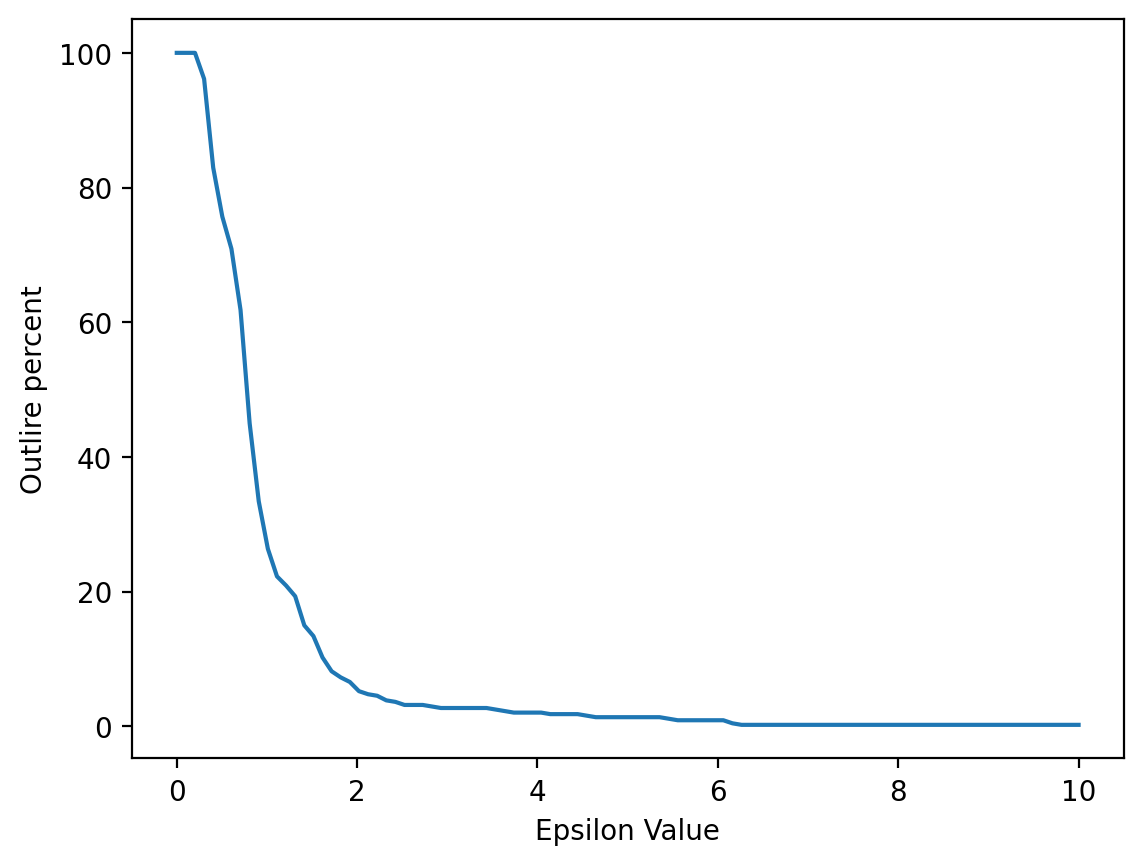

In [16]:
sns.lineplot(x = np.linspace(0.001, 10, 100), y = outlier_percent)
plt.ylabel('Outlire percent')
plt.xlabel('Epsilon Value')

In [17]:
dbscan = DBSCAN(eps = 2, min_samples = 16)

In [18]:
dbscan_labels = dbscan.fit_predict(scaled_data)

In [19]:
data['labels'] = dbscan_labels

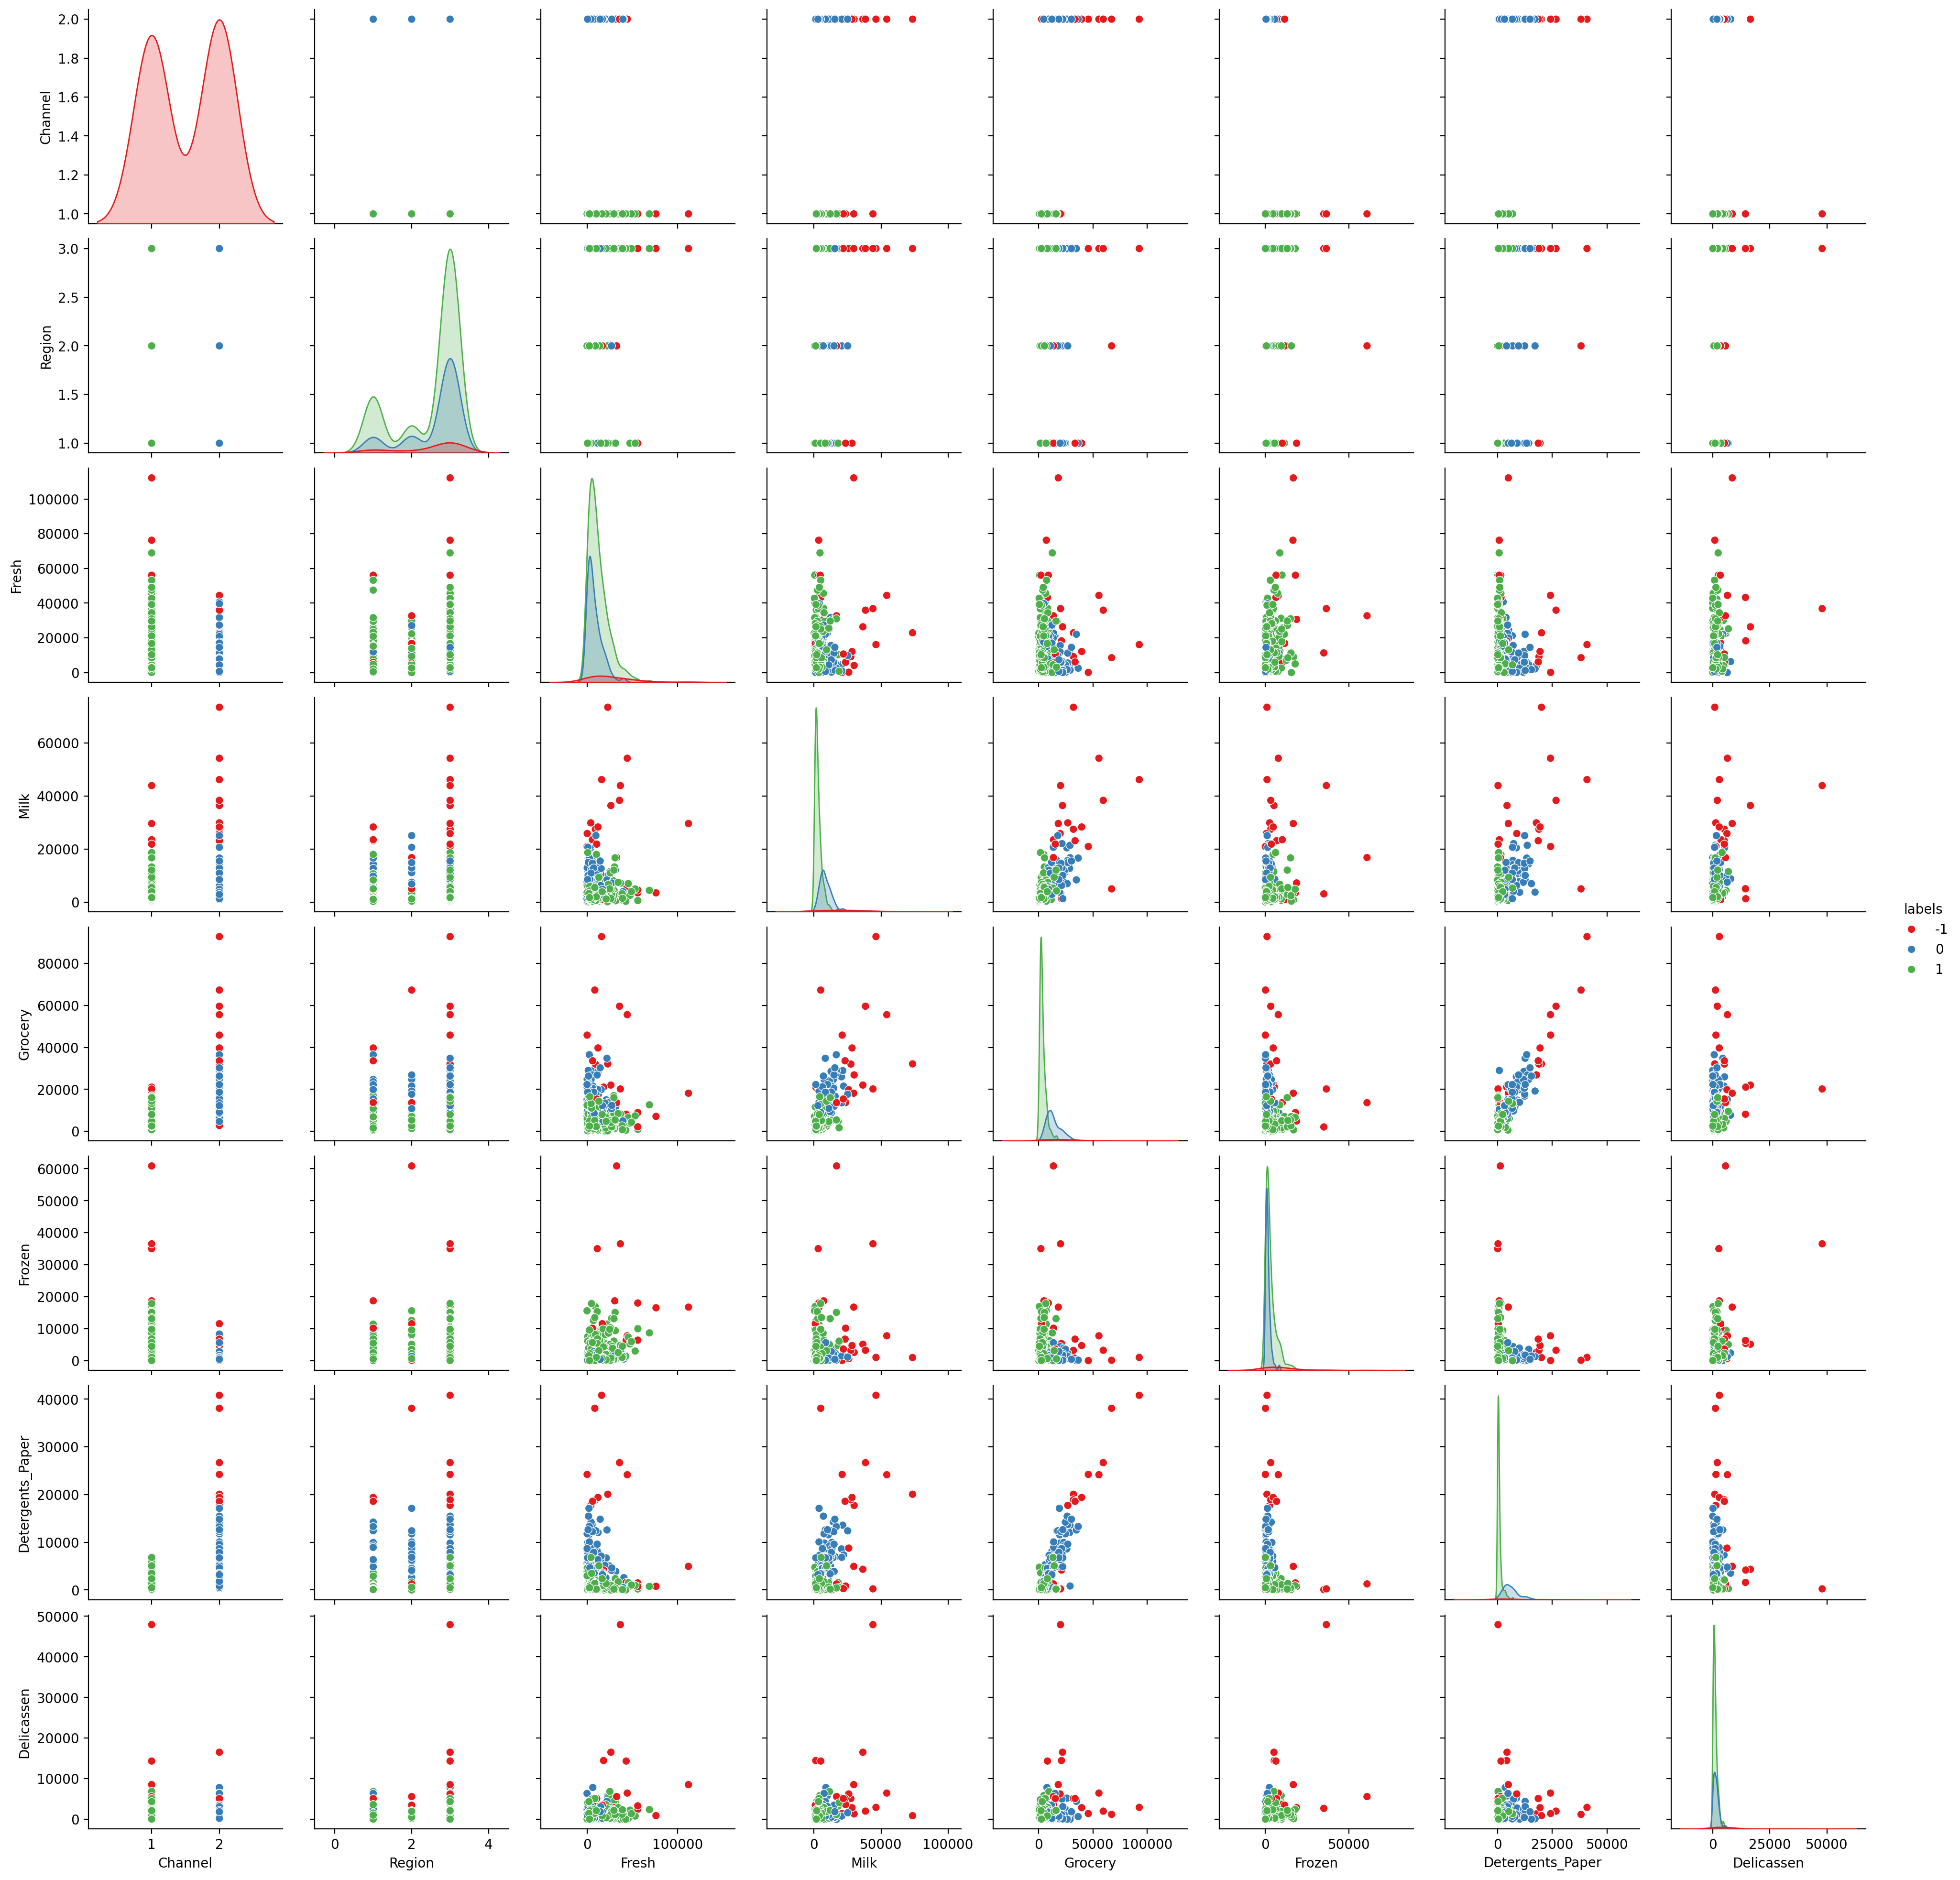

In [20]:
sns.pairplot(data, hue = 'labels', palette = 'Set1')

<Axes: xlabel='Grocery', ylabel='Milk'>

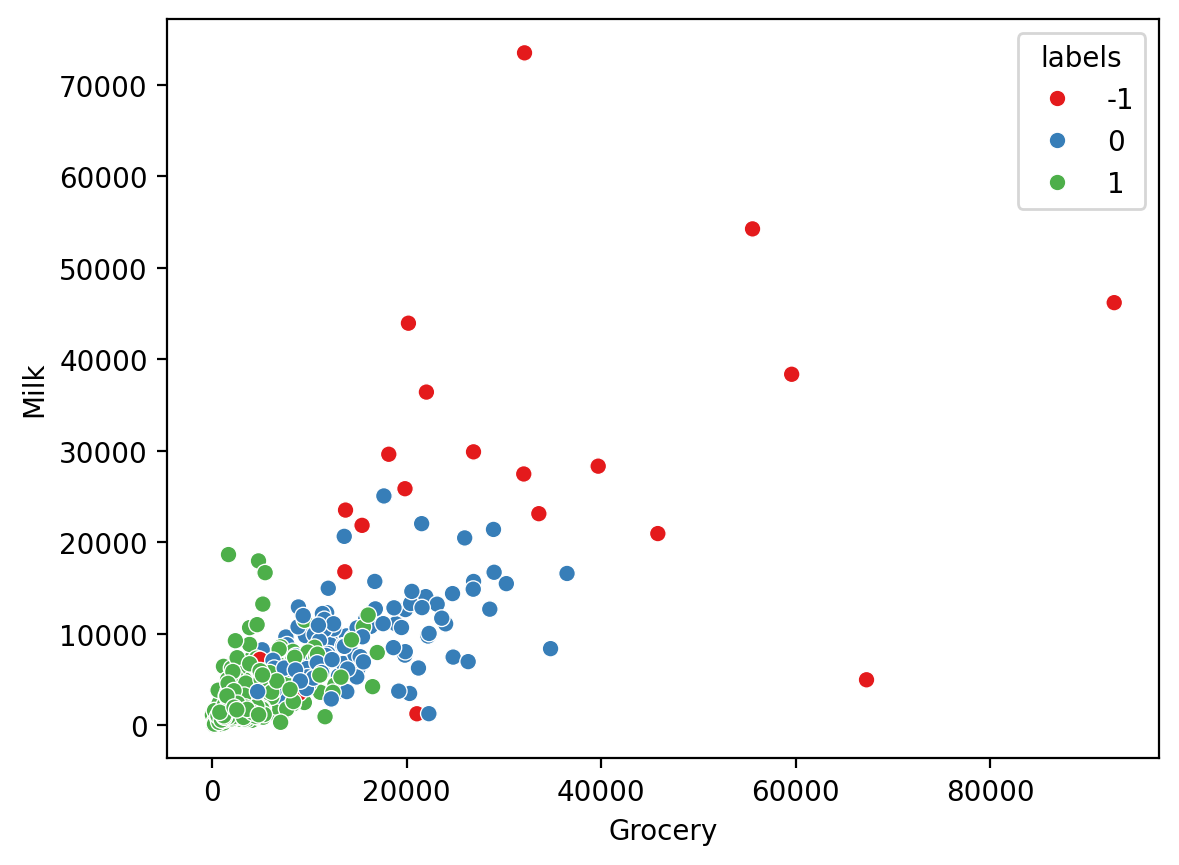

In [21]:
sns.scatterplot(x = 'Grocery', y = 'Milk', hue = 'labels', data = data, palette = 'Set1')

<Axes: xlabel='Detergents_Paper', ylabel='Milk'>

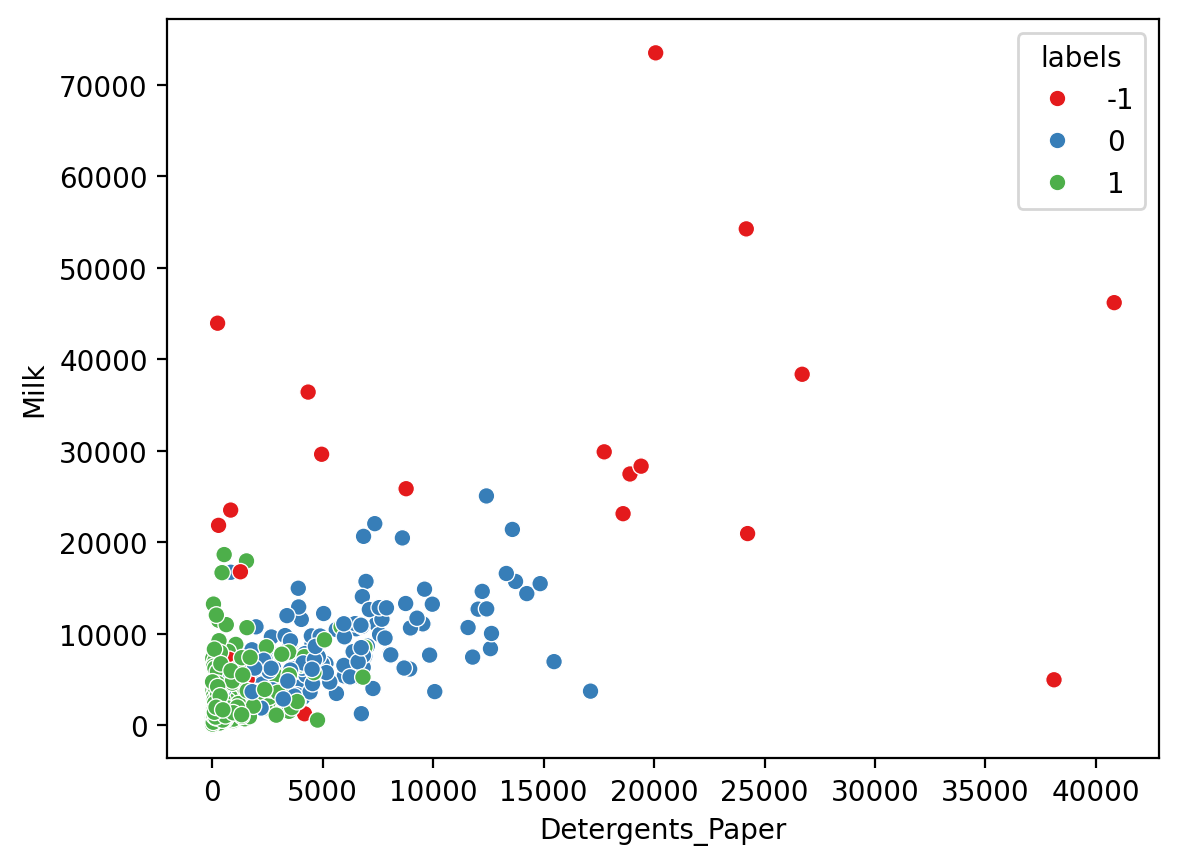

In [22]:
sns.scatterplot(x = 'Detergents_Paper', y = 'Milk', hue = 'labels', data = data, palette = 'Set1')

In [23]:
label_means = data.groupby('labels')[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].mean()

In [24]:
label_means

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
labels,,,,,,
-1,27729.920000,22966.960000,26609.600000,11289.640000,11173.560000,6707.160000
0,8227.666667,8615.852713,13859.674419,1447.759690,5969.581395,1498.457364
1,12326.972028,3023.559441,3655.328671,3086.181818,763.783217,1083.786713


In [25]:
minmax = MinMaxScaler()

In [26]:
labels_df = pd.DataFrame(minmax.fit_transform(label_means), columns = [['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']])

In [27]:
labels_df

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.000000,0.280408,0.444551,0.000000,0.500087,0.073741
2,0.210196,0.000000,0.000000,0.166475,0.000000,0.000000


<Axes: xlabel='None'>

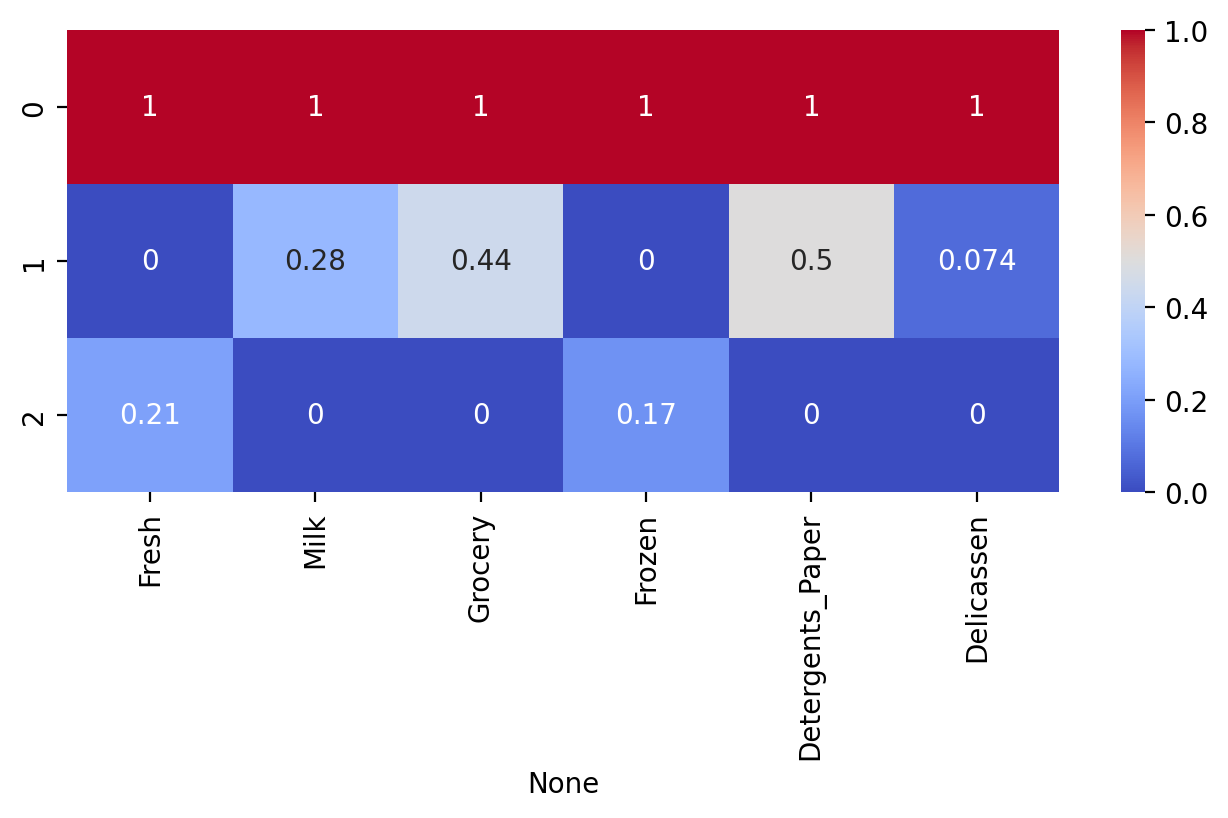

In [28]:
plt.figure(figsize = (8, 3))
sns.heatmap(labels_df, annot = True, cmap = 'coolwarm')

<Axes: xlabel='None'>

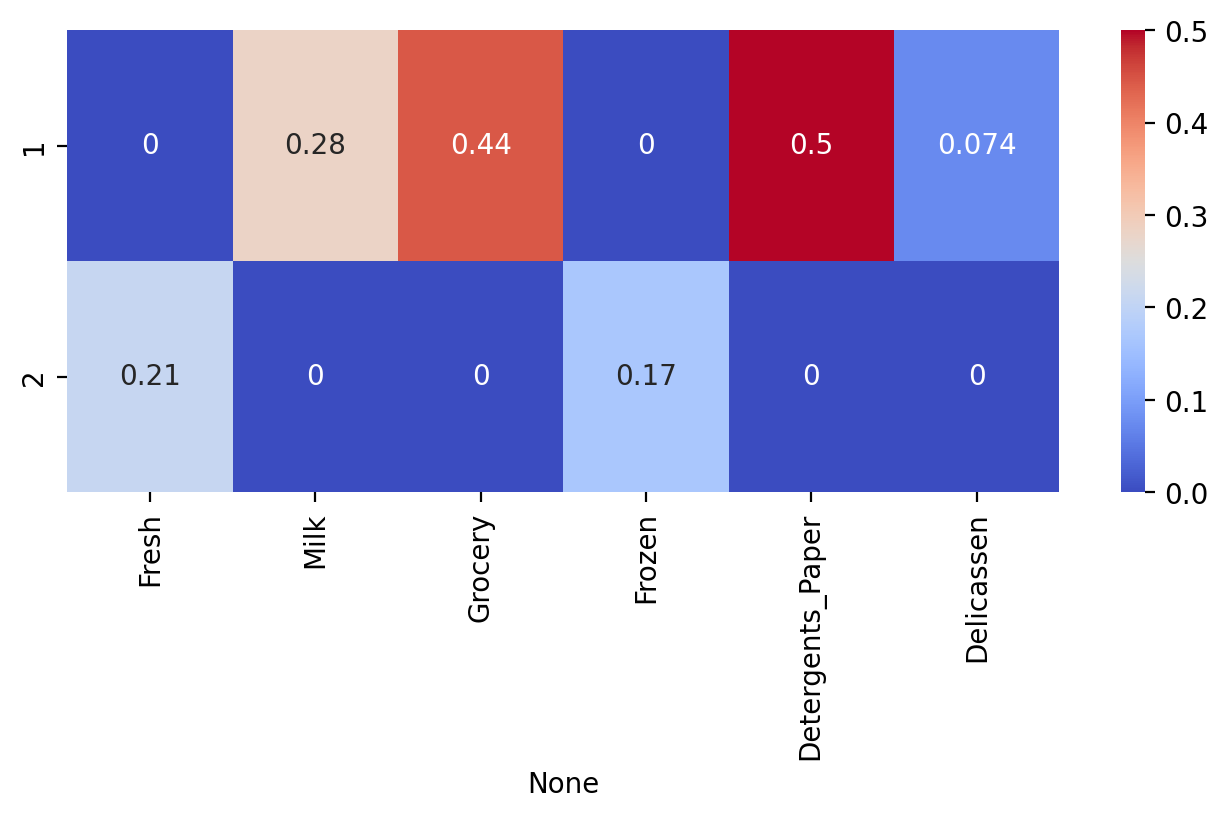

In [29]:
plt.figure(figsize = (8, 3))
sns.heatmap(labels_df.loc[[1, 2]], annot = True, cmap = 'coolwarm')